# 08_fusion_dev — Lightsheet Fusion Parameter Sweep

**Kernel:** Python (spatialdata_2025)
**GPU execution:** Cell 2 runs 07_direct_fuse.py in lightsheet_env via subprocess (CUDA loaded inside subprocess).

## Workflow
1. Edit `PARAMS` in Cell 1 to set substack range and fusion parameters.
2. Run Cell 2 to execute fusion (≈16 min on A100 GPU node).
3. Run Cells 3–5 for diagnostics.
4. Run Cell 6 to print `best_params` for copy-paste into `07_direct_fuse.sh`.

**Prerequisites:** Run this notebook on an interactive GPU node (`srun --gres=gpu:A100:1 --pty bash` then launch JupyterLab).
If running from a login node, Cell 2 will fall back to CPU (NumPy) and take ~3–4 hours — not recommended.

In [1]:
# ── PARAMETERS ─────────────────────────────────────────────────────────────
# Edit values here, then re-run Cell 2 to fuse with updated parameters.
# Parameters to sweep for seam/artifact reduction:
#   taper_px:        validated at 288 (288 px taper on 1920 px tile)
#   sigma_frac:      validated at 0.9 (broad Gaussian for dual-side blend)
#   ncc_threshold:   validated at 0.5
#   normalize_tiles: True (recommended — scales per-tile median to fix striation seams)
#   fusion_axis:     2=X (correct for KL018 Z.1 dual-side illumination)

PARAMS = {
    "z_start":         527,   # inclusive, first Z of substack
    "z_end":           528,   # exclusive, last Z of substack (100 planes)
    "sigma_frac":      0.6,   # Gaussian blend sigma fraction
    "taper_px":        64,   # cosine taper width in pixels
    "ncc_threshold":   0.9,   # NCC quality threshold for phase-correlation
    "fusion_axis":     2,     # 2=X axis (dual-side illumination along X for KL018)
    "normalize_tiles": True,  # scale per-tile median to global median (reduces striation seams)
    "skip_refine":     False, # set True to skip NCC refinement (use raw stage positions)
    "z_chunk":         64,    # Z planes per processing slab
    "workers":         8,     # parallel CZI read threads
}

# ── PATHS ───────────────────────────────────────────────────────────────────
LIGHTSHEET_ENV = "/vast/scratch/users/kriel.j/lightsheet_env"
SCRIPT         = "/vast/projects/BCRL_Multi_Omics/scripts/lightsheet_pipeline/07_direct_fuse.py"
CZI_PATH       = "/vast/scratch/users/kriel.j/KL018_lightsheet/KL018_85_D7_CT2AvIII_Overview.czi"
OUT_DIR        = "/vast/scratch/users/kriel.j/KL018_lightsheet"
OUT_ZARR       = f"{OUT_DIR}/substack_z{PARAMS['z_start']}_{PARAMS['z_end']}.zarr"

print("PARAMS:")
for k, v in PARAMS.items():
    print(f"  {k:20s} = {v}")
print(f"\nOutput zarr: {OUT_ZARR}")

PARAMS:
  z_start              = 527
  z_end                = 528
  sigma_frac           = 0.6
  taper_px             = 64
  ncc_threshold        = 0.9
  fusion_axis          = 2
  normalize_tiles      = True
  skip_refine          = False
  z_chunk              = 64
  workers              = 8

Output zarr: /vast/scratch/users/kriel.j/KL018_lightsheet/substack_z527_528.zarr


In [2]:
import subprocess, sys

# Build CLI argument list from PARAMS
cli_args = [
    "--czi",            CZI_PATH,
    "--out",            OUT_ZARR,
    "--z-start",        str(PARAMS["z_start"]),
    "--z-end",          str(PARAMS["z_end"]),
    "--sigma-frac",     str(PARAMS["sigma_frac"]),
    "--taper-px",       str(PARAMS["taper_px"]),
    "--ncc-threshold",  str(PARAMS["ncc_threshold"]),
    "--fusion-axis",    str(PARAMS["fusion_axis"]),
    "--z-chunk",        str(PARAMS["z_chunk"]),
    "--workers",        str(PARAMS["workers"]),
]
if PARAMS.get("normalize_tiles"):
    cli_args.append("--normalize-tiles")
if PARAMS.get("skip_refine"):
    cli_args.append("--skip-refine")

# Use bash -c with module load CUDA/12.1 to ensure CuPy finds the correct CUDA toolkit.
# Mirrors the pattern in 07_direct_fuse.sh lines 41-44.
python_in_env = f"{LIGHTSHEET_ENV}/bin/python"
args_str = " ".join(cli_args)
bash_cmd = f"module load CUDA/12.1 2>/dev/null || true; {python_in_env} {SCRIPT} {args_str}"

print("Running fusion...")
print(f"  cmd: bash -c '{bash_cmd[:120]}...'")

result = subprocess.run(
    ["bash", "-c", bash_cmd],
    capture_output=True,
    text=True,
)

# Print last 4000 chars of stdout (progress bars, chunk completions)
print(result.stdout[-4000:] if len(result.stdout) > 4000 else result.stdout)
if result.returncode != 0:
    print("\n── STDERR ──────────────────────────────────")
    print(result.stderr[-2000:])
    raise RuntimeError(f"07_direct_fuse.py exited with code {result.returncode}")
else:
    print(f"\nDone. Zarr written to: {OUT_ZARR}")

Running fusion...
  cmd: bash -c 'module load CUDA/12.1 2>/dev/null || true; /vast/scratch/users/kriel.j/lightsheet_env/bin/python /vast/projects/BCRL_Mul...'
ghtsheet/ncc_scores.json
  Refined canvas: 10079×8448 (was 10079×8448)

Computing per-tile intensity normalization (overlap-region matching)...
  Reading mid-Z planes for overlap normalization (C=0, Z=778) ...
  Overlap normalization: scale_range=[0.947, 1.047]  (29 MST edges)
  Reading mid-Z planes for overlap normalization (C=1, Z=778) ...
  Overlap normalization: scale_range=[0.956, 1.044]  (29 MST edges)

Creating output zarr: shape=(1, 2, 1, 8448, 10079)  chunks=(1, 1, 64, 512, 512)

=== T=0  C=0 ===
  Z-chunk 1/1  z=527:528  [####################################] 1/1 (100%)
    tile [----------------------------] 1/30 (3%)
    tile [#---------------------------] 2/30 (7%)
    tile [##--------------------------] 3/30 (10%)
    tile [###-------------------------] 4/30 (13%)
    tile [####------------------------] 5/30 (17%)
 

Opening /vast/scratch/users/kriel.j/KL018_lightsheet/substack_z527_528.zarr ...
  Shape (TCZYX): (1, 2, 1, 8448, 10079)   dtype: uint16   chunks: (1, 1, 64, 512, 512)
  Displaying Z=527 (local index 0), channel 0, 1/8 downsample


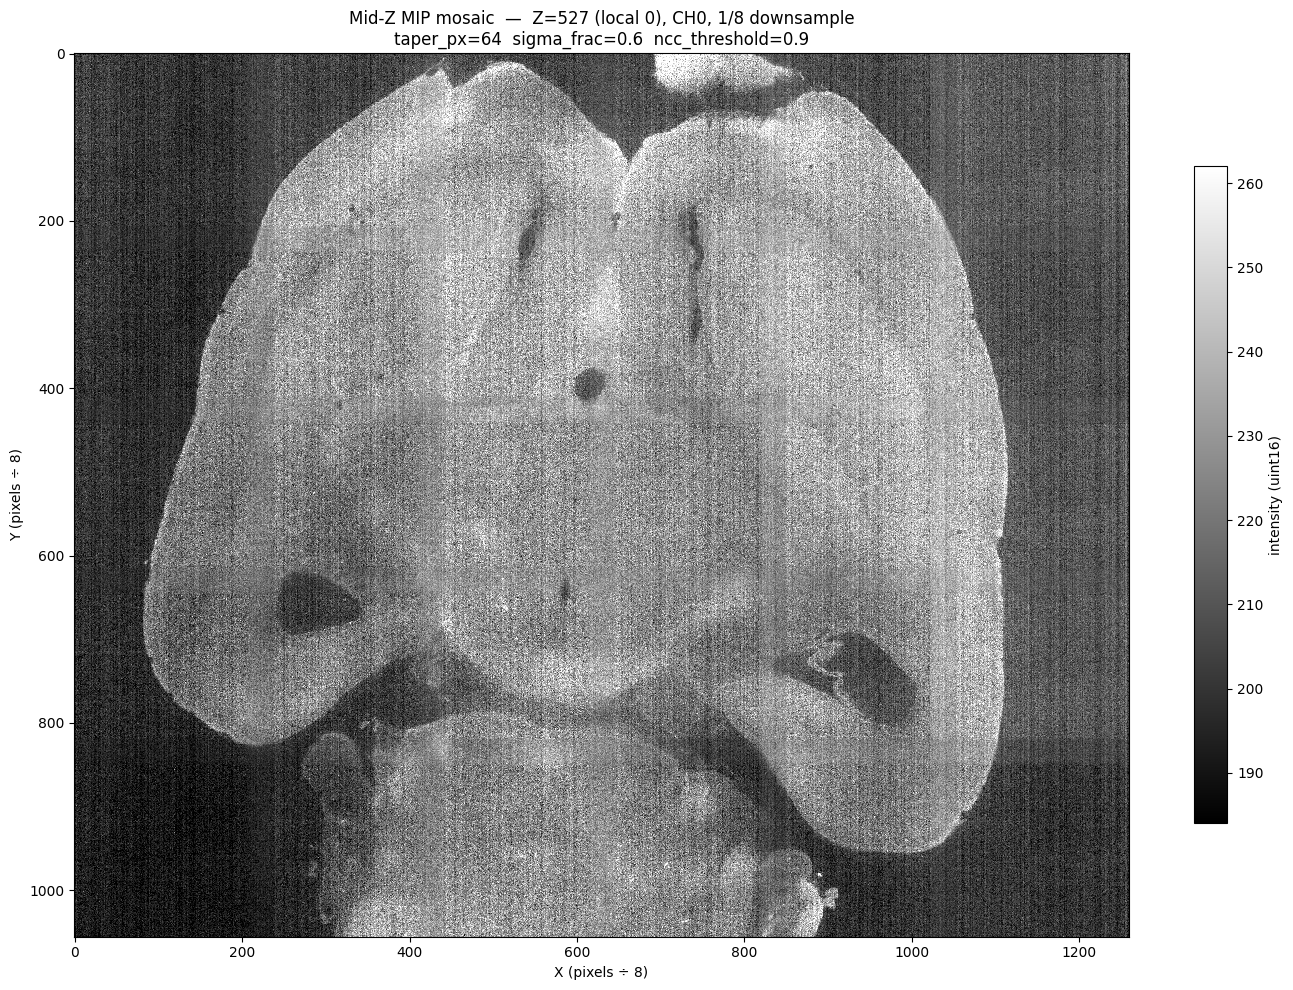

  pixel range [p1, p99]: [184, 262]  array shape: (1056, 1260)


In [2]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"Opening {OUT_ZARR} ...")
z = zarr.open(OUT_ZARR, mode="r")
print(f"  Shape (TCZYX): {z.shape}   dtype: {z.dtype}   chunks: {z.chunks}")

# Mid-local-Z index (50 for 100-slice substack)
mid_loc = z.shape[2] // 2
mid_abs = PARAMS["z_start"] + mid_loc
print(f"  Displaying Z={mid_abs} (local index {mid_loc}), channel 0, 1/8 downsample")

# Load at 1/8 downsample to keep array ~3 MB
plane = z[0, 0, mid_loc, ::8, ::8]

p1  = np.percentile(plane, 1)
p99 = np.percentile(plane, 99)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(plane, cmap="gray", vmin=p1, vmax=p99, interpolation="nearest")
ax.set_title(
    f"Mid-Z MIP mosaic  —  Z={mid_abs} (local {mid_loc}), CH0, 1/8 downsample\n"
    f"taper_px={PARAMS['taper_px']}  sigma_frac={PARAMS['sigma_frac']}  "
    f"ncc_threshold={PARAMS['ncc_threshold']}"
)
ax.set_xlabel("X (pixels ÷ 8)")
ax.set_ylabel("Y (pixels ÷ 8)")
plt.colorbar(im, ax=ax, label="intensity (uint16)", fraction=0.025)
plt.tight_layout()
plt.show()
print(f"  pixel range [p1, p99]: [{p1:.0f}, {p99:.0f}]  array shape: {plane.shape}")

Opening /vast/scratch/users/kriel.j/KL018_lightsheet/substack_z527_528.zarr ...
  Shape (TCZYX): (1, 2, 1, 8448, 10079)   dtype: uint16   chunks: (1, 1, 64, 512, 512)
  Displaying Z=527 (local index 0), channel 0, 1/8 downsample


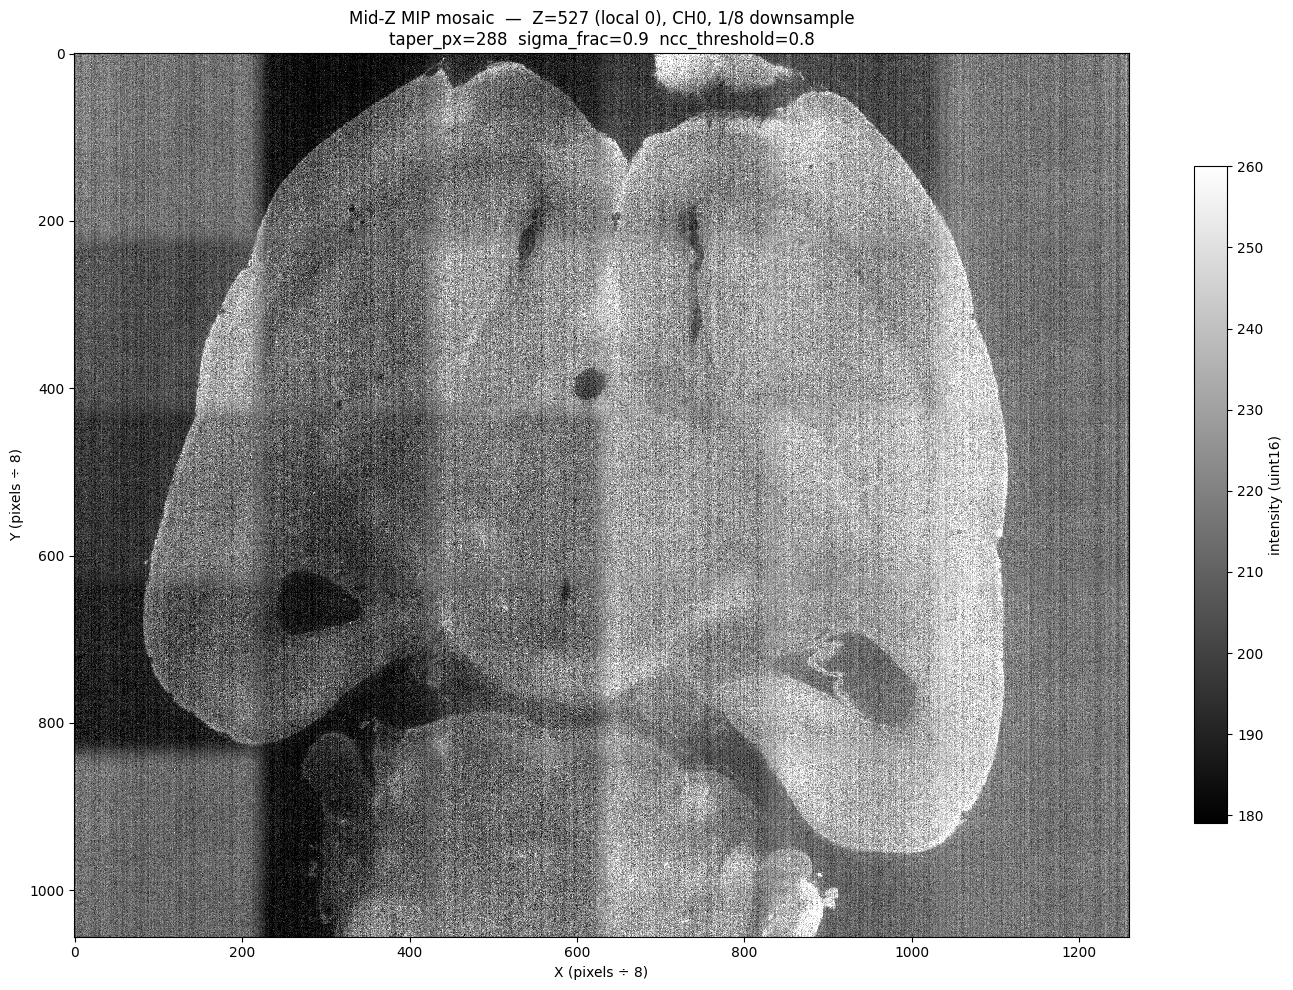

  pixel range [p1, p99]: [179, 260]  array shape: (1056, 1260)


In [6]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"Opening {OUT_ZARR} ...")
z = zarr.open(OUT_ZARR, mode="r")
print(f"  Shape (TCZYX): {z.shape}   dtype: {z.dtype}   chunks: {z.chunks}")

# Mid-local-Z index (50 for 100-slice substack)
mid_loc = z.shape[2] // 2
mid_abs = PARAMS["z_start"] + mid_loc
print(f"  Displaying Z={mid_abs} (local index {mid_loc}), channel 0, 1/8 downsample")

# Load at 1/8 downsample to keep array ~3 MB
plane = z[0, 0, mid_loc, ::8, ::8]

p1  = np.percentile(plane, 1)
p99 = np.percentile(plane, 99)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(plane, cmap="gray", vmin=p1, vmax=p99, interpolation="nearest")
ax.set_title(
    f"Mid-Z MIP mosaic  —  Z={mid_abs} (local {mid_loc}), CH0, 1/8 downsample\n"
    f"taper_px={PARAMS['taper_px']}  sigma_frac={PARAMS['sigma_frac']}  "
    f"ncc_threshold={PARAMS['ncc_threshold']}"
)
ax.set_xlabel("X (pixels ÷ 8)")
ax.set_ylabel("Y (pixels ÷ 8)")
plt.colorbar(im, ax=ax, label="intensity (uint16)", fraction=0.025)
plt.tight_layout()
plt.show()
print(f"  pixel range [p1, p99]: [{p1:.0f}, {p99:.0f}]  array shape: {plane.shape}")

Loading NCC scores from: /vast/scratch/users/kriel.j/KL018_lightsheet/ncc_scores.json
  30 tiles  |  mid_z used for NCC: 778  |  threshold: 0.9
  quality matrix shape: (30, 30)  range: [-0.006, 0.776]


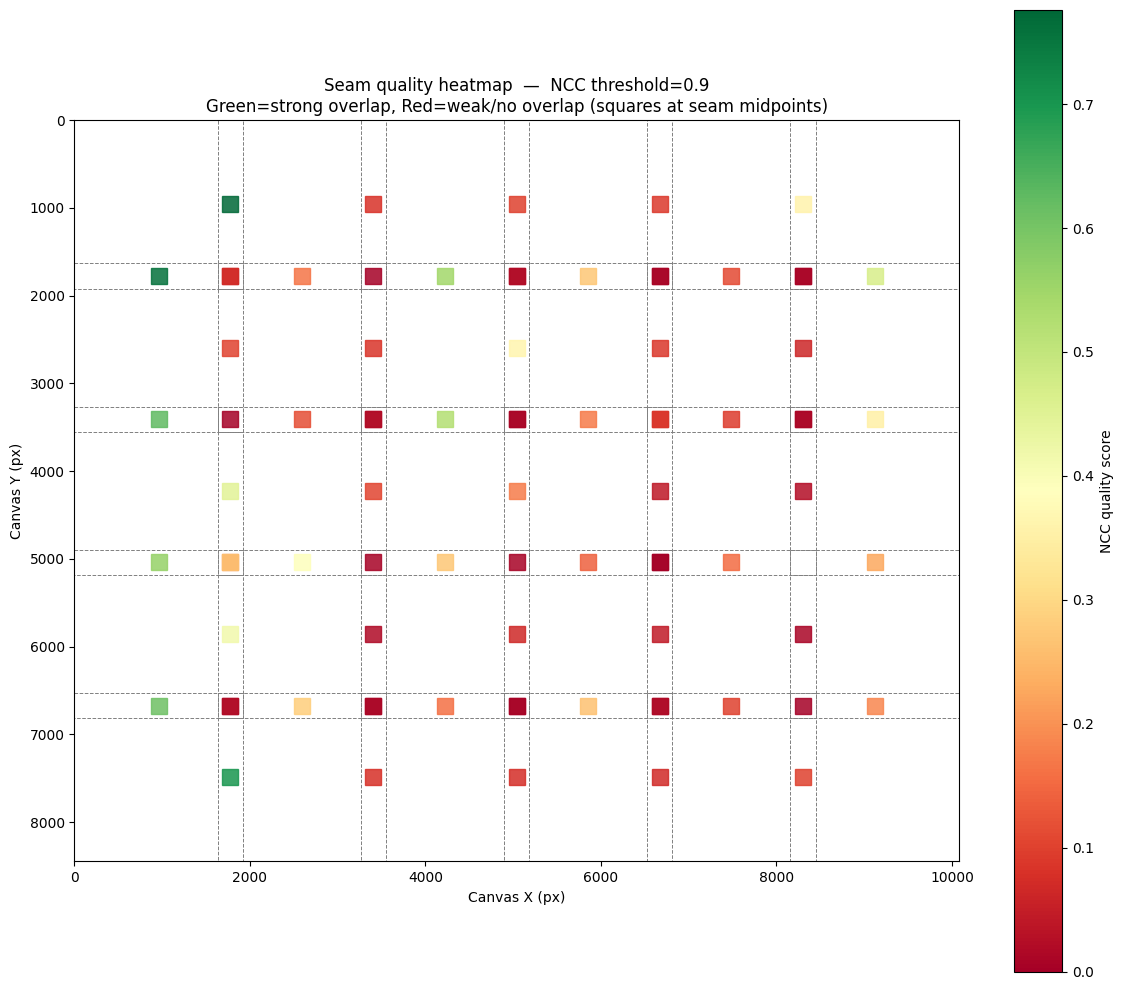

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

ncc_path = f"{OUT_DIR}/ncc_scores.json"
print(f"Loading NCC scores from: {ncc_path}")
with open(ncc_path) as f:
    ncc_data = json.load(f)

quality   = np.array(ncc_data["quality_matrix"])   # (n_tiles, n_tiles)
tile_pos  = ncc_data["tile_positions_refined"]      # list of {M, x, y, w, h} absolute coords
mid_z_ncc = ncc_data["mid_z"]
ncc_thresh = ncc_data["ncc_threshold"]

print(f"  {len(tile_pos)} tiles  |  mid_z used for NCC: {mid_z_ncc}  |  threshold: {ncc_thresh}")
print(f"  quality matrix shape: {quality.shape}  "
      f"range: [{quality.min():.3f}, {quality.max():.3f}]")

# Canvas origin — compute first so centers are in canvas-relative space
canvas_ox = min(p["x"] for p in tile_pos)
canvas_oy = min(p["y"] for p in tile_pos)

# Build tile-center lookup in canvas-relative coordinates
centers = {p["M"]: (p["x"] - canvas_ox + p["w"] // 2, p["y"] - canvas_oy + p["h"] // 2) for p in tile_pos}

fig, ax = plt.subplots(figsize=(12, 10))
norm = Normalize(vmin=0, vmax=max(quality.max(), 1e-6))
cmap = plt.cm.RdYlGn

# Plot a colored square at each seam midpoint between adjacent tile pairs
n = len(tile_pos)
for i in range(n):
    for j in range(i + 1, n):
        q = quality[i][j]
        if q > 0:
            cx = (centers[i][0] + centers[j][0]) / 2
            cy = (centers[i][1] + centers[j][1]) / 2
            ax.plot(cx, cy, "s", color=cmap(norm(q)), markersize=12, alpha=0.85)

# Draw tile outlines in canvas-relative coordinates
for p in tile_pos:
    rect = plt.Rectangle(
        (p["x"] - canvas_ox, p["y"] - canvas_oy), p["w"], p["h"],
        fill=False, edgecolor="gray", linewidth=0.7, linestyle="--"
    )
    ax.add_patch(rect)
    ax.text(
        p["x"] - canvas_ox + p["w"] // 2,
        p["y"] - canvas_oy + p["h"] // 2,
        str(p["M"]), ha="center", va="center", fontsize=7, color="white", alpha=0.6
    )

ax.set_xlim(0, max(p["x"] - canvas_ox + p["w"] for p in tile_pos))
ax.set_ylim(max(p["y"] - canvas_oy + p["h"] for p in tile_pos), 0)
ax.set_aspect("equal")
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="NCC quality score")
ax.set_title(
    f"Seam quality heatmap  —  NCC threshold={ncc_thresh}\n"
    f"Green=strong overlap, Red=weak/no overlap (squares at seam midpoints)"
)
ax.set_xlabel("Canvas X (px)")
ax.set_ylabel("Canvas Y (px)")
plt.tight_layout()
plt.show()

Loading mid-Z plane (Z local=0, shape 8448×10079) ...


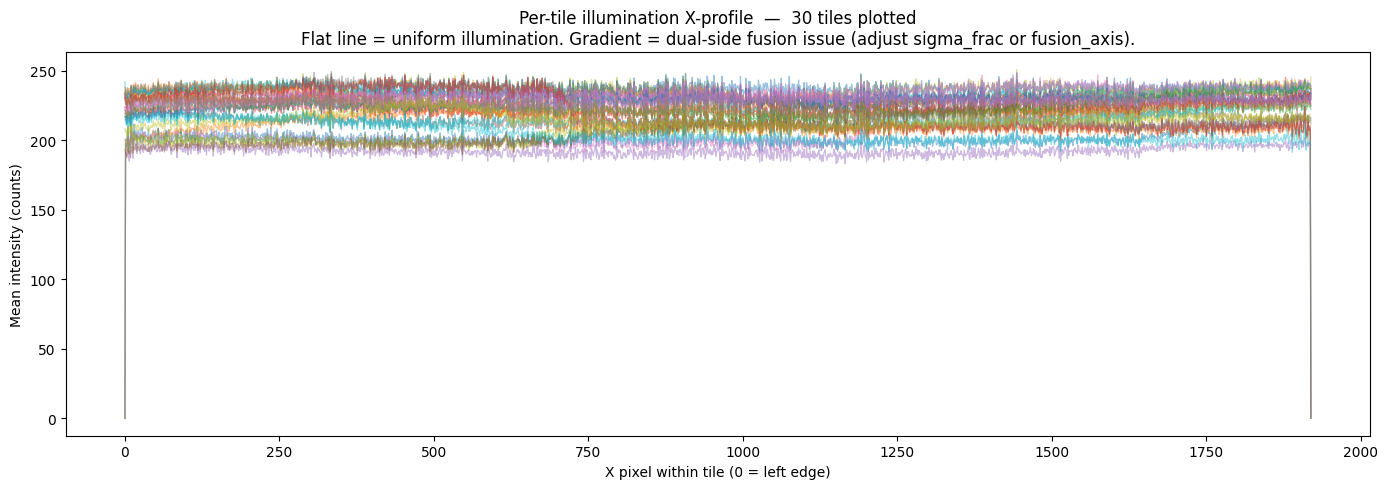

  Plotted 30/30 tiles


In [4]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import json

# Reload zarr handle if kernel was restarted
z_arr = zarr.open(OUT_ZARR, mode="r")
mid_loc = z_arr.shape[2] // 2

# Load full mid-Z plane for tile crops (188 MB, uint16 — OK for spatialdata_env_2)
print(f"Loading mid-Z plane (Z local={mid_loc}, shape {z_arr.shape[3]}×{z_arr.shape[4]}) ...")
plane_full = z_arr[0, 0, mid_loc, :, :]   # (canvas_H, canvas_W) uint16

# Use tile positions from ncc_scores.json (absolute canvas coords)
# Offset to canvas-relative coords using min(x) and min(y) as origin
canvas_ox_abs = min(p["x"] for p in tile_pos)
canvas_oy_abs = min(p["y"] for p in tile_pos)

fig, ax = plt.subplots(figsize=(14, 5))
n_plotted = 0
for p in tile_pos:
    x0 = p["x"] - canvas_ox_abs
    y0 = p["y"] - canvas_oy_abs
    x1 = x0 + p["w"]
    y1 = y0 + p["h"]

    # Clip to canvas bounds (refined canvas may be slightly smaller than max extent)
    x0c = max(x0, 0)
    y0c = max(y0, 0)
    x1c = min(x1, plane_full.shape[1])
    y1c = min(y1, plane_full.shape[0])
    if x1c <= x0c or y1c <= y0c:
        continue

    tile_crop = plane_full[y0c:y1c, x0c:x1c]
    # Mean along Y axis → 1D profile across X showing illumination gradient
    profile = tile_crop.mean(axis=0)
    ax.plot(profile, alpha=0.45, linewidth=0.9, label=f"M{p['M']}")
    n_plotted += 1

ax.set_xlabel("X pixel within tile (0 = left edge)")
ax.set_ylabel("Mean intensity (counts)")
ax.set_title(
    f"Per-tile illumination X-profile  —  {n_plotted} tiles plotted\n"
    f"Flat line = uniform illumination. Gradient = dual-side fusion issue (adjust sigma_frac or fusion_axis)."
)
# Only show legend if ≤10 tiles (30 tiles makes legend unreadable)
if n_plotted <= 10:
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()
print(f"  Plotted {n_plotted}/{len(tile_pos)} tiles")
del plane_full  # free ~188 MB

Loading mid-Z plane (local=0) ...
Overlap scale range: [0.832, 1.202]  CV=9.5%  (29 MST edges)
If all scales ≈ 1.0 → tiles are already well-matched; normalization is a no-op.


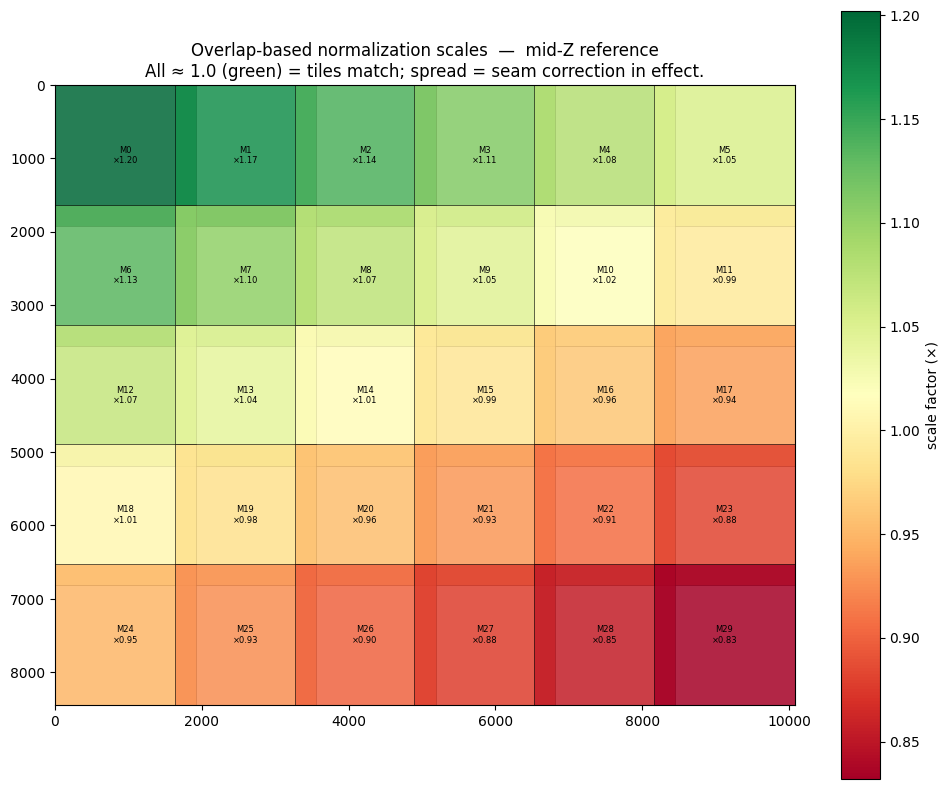

In [6]:
# ── Cell 6b: Overlap normalization diagnostic ──────────────────────────────
# Replicates compute_overlap_norm_scales() in Python to preview the per-tile
# scale factors that --normalize-tiles will apply.
# Run after Cell 3 (which loads tile_pos from ncc_scores.json).
# The zarr canvas is used as the mid-Z reference — no re-read of the CZI needed.

import zarr, json, math, numpy as np, matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize as MplNorm

z_arr = zarr.open(OUT_ZARR, mode="r")
mid_loc = z_arr.shape[2] // 2
print(f"Loading mid-Z plane (local={mid_loc}) ...")
plane = np.array(z_arr[0, 0, mid_loc, :, :])  # (H, W) uint16

canvas_ox = min(p["x"] for p in tile_pos)
canvas_oy = min(p["y"] for p in tile_pos)
n = len(tile_pos)
pos_m = {p["M"]: p for p in tile_pos}

log_ratios = {}
ovlap_q = np.zeros((n, n), dtype=np.float32)

for i in range(n):
    for j in range(i + 1, n):
        pi, pj = pos_m[i], pos_m[j]
        ox0 = max(pi["x"], pj["x"]);  ox1 = min(pi["x"]+pi["w"], pj["x"]+pj["w"])
        oy0 = max(pi["y"], pj["y"]);  oy1 = min(pi["y"]+pi["h"], pj["y"]+pj["h"])
        if ox1 - ox0 < 16 or oy1 - oy0 < 16:
            continue
        def _crop(p):
            rx = p["x"] - canvas_ox;  ry = p["y"] - canvas_oy
            return plane[oy0-canvas_oy-ry : oy0-canvas_oy-ry+(oy1-oy0),
                         ox0-canvas_ox-rx : ox0-canvas_ox-rx+(ox1-ox0)].astype(np.float32)
        mi, mj = _crop(pi).mean(), _crop(pj).mean()
        if mi < 1 or mj < 1:
            continue
        ovlap_q[i, j] = ovlap_q[j, i] = min(mi, mj)
        log_ratios[(i, j)] =  math.log(mi / mj)
        log_ratios[(j, i)] = -log_ratios[(i, j)]

mst   = minimum_spanning_tree(csr_matrix(-ovlap_q * (ovlap_q > 0))).toarray()
edges = list(zip(*np.where(mst != 0)))

log_sc = {0: 0.0}
q, vis = [0], {0}
while q:
    src = q.pop(0)
    for ei, ej in edges:
        nbr = ej if ei == src else (ei if ej == src else None)
        if nbr is None or nbr in vis: continue
        log_sc[nbr] = log_sc[src] - log_ratios.get((src, nbr), 0.0)
        vis.add(nbr); q.append(nbr)
for m in range(n):
    if m not in log_sc: log_sc[m] = 0.0

mean_log = sum(log_sc[m] for m in range(n)) / n
scales = {m: float(np.clip(math.exp(log_sc[m] - mean_log), 0.5, 2.0)) for m in range(n)}

vals = np.array(list(scales.values()))
print(f"Overlap scale range: [{vals.min():.3f}, {vals.max():.3f}]  "
      f"CV={vals.std()/vals.mean()*100:.1f}%  ({len(edges)} MST edges)")
print("If all scales ≈ 1.0 → tiles are already well-matched; normalization is a no-op.")

norm_p = MplNorm(vmin=min(0.9, vals.min()), vmax=max(1.1, vals.max()))
cmap   = plt.cm.RdYlGn
fig, ax = plt.subplots(figsize=(10, 8))
for p in tile_pos:
    xr = p["x"] - canvas_ox;  yr = p["y"] - canvas_oy
    rect = plt.Rectangle((xr, yr), p["w"], p["h"],
                          facecolor=cmap(norm_p(scales[p["M"]])),
                          edgecolor="k", lw=0.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(xr + p["w"]//2, yr + p["h"]//2,
            f"M{p['M']}\n×{scales[p['M']]:.2f}",
            ha="center", va="center", fontsize=6)
ax.set_xlim(0, max(p["x"]-canvas_ox+p["w"] for p in tile_pos))
ax.set_ylim(max(p["y"]-canvas_oy+p["h"] for p in tile_pos), 0)
ax.set_aspect("equal")
fig.colorbar(ScalarMappable(norm=norm_p, cmap=cmap), ax=ax, label="scale factor (×)")
ax.set_title("Overlap-based normalization scales  —  mid-Z reference\n"
             "All ≈ 1.0 (green) = tiles match; spread = seam correction in effect.")
plt.tight_layout(); plt.show()
del plane

In [7]:
# ── COPY-PASTE OUTPUT FOR 07_direct_fuse.sh ─────────────────────────────────
# After visual inspection of Cells 3–5, update PARAMS in Cell 1 to the
# values that produced the best fusion quality, then run this cell.
# Copy the printed lines into 07_direct_fuse.sh to replace the current flags.

best_params = {
    "sigma_frac":      PARAMS["sigma_frac"],
    "taper_px":        PARAMS["taper_px"],
    "ncc_threshold":   PARAMS["ncc_threshold"],
    "fusion_axis":     PARAMS["fusion_axis"],
    "normalize_tiles": PARAMS.get("normalize_tiles", False),
    "z_chunk":         PARAMS["z_chunk"],
    "workers":         PARAMS["workers"],
    # skip_refine intentionally excluded — use only if NCC is failing
}

print("# ── Paste into 07_direct_fuse.sh (replace current python call flags) ──────")
print(f'python "${{SCRIPT_DIR}}/07_direct_fuse.py" \\')
print(f'    --czi      "$CZI_ARG" \\')
for k, v in best_params.items():
    if k == "normalize_tiles":
        if v:
            print(f"    --normalize-tiles \\")
        continue
    flag = k.replace("_", "-")
    print(f"    --{flag:<18} {v} \\")
if PARAMS.get("skip_refine"):
    print("    --skip-refine \\")
print("    ;")

print("\n# ── Full best_params dict (for records) ────────────────────────────────────")
print("best_params =", best_params)

# ── Paste into 07_direct_fuse.sh (replace current python call flags) ──────
python "${SCRIPT_DIR}/07_direct_fuse.py" \
    --czi      "$CZI_ARG" \
    --sigma-frac         0.6 \
    --taper-px           64 \
    --ncc-threshold      0.9 \
    --fusion-axis        2 \
    --normalize-tiles \
    --z-chunk            64 \
    --workers            8 \
    ;

# ── Full best_params dict (for records) ────────────────────────────────────
best_params = {'sigma_frac': 0.6, 'taper_px': 64, 'ncc_threshold': 0.9, 'fusion_axis': 2, 'normalize_tiles': True, 'z_chunk': 64, 'workers': 8}


In [8]:
# ── Phase 2.5: Stitching Diagnostics ──────────────────────────────────────
# STITCH-04: renders stitch_diagnostics.json + stitch_positions.json produced
# by `08_stitch.py --stage register` (mvstitch_env). Reads the pre-existing
# fused_direct.zarr at OUT_ZARR for the per-tile illumination crop.
#
# Targets (RESEARCH §Validation Strategy):
#   - Solver convergence True
#   - Mean pairwise NCC ≥ 0.85
#   - Max residual_px ≤ ~5
#   - Per-tile illumination max/min ≤ 1.15

import json
import zarr
import numpy as np
import matplotlib.pyplot as plt

diag = json.load(open(f"{OUT_DIR}/stitch_diagnostics.json"))
pos  = json.load(open(f"{OUT_DIR}/stitch_positions.json"))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
n = diag["n_tiles"]

# Panel 1: pairwise residual translation (px)
res = np.full((n, n), np.nan)
for edge in diag["pairwise"]:
    i, j = edge["i"], edge["j"]
    res[i, j] = res[j, i] = edge["residual_px"]
im0 = axes[0].imshow(res, cmap="viridis", vmin=0, vmax=5)
axes[0].set_title("Pairwise residual translation (px)")
axes[0].set_xlabel("tile j"); axes[0].set_ylabel("tile i")
plt.colorbar(im0, ax=axes[0])

# Panel 2: pairwise NCC quality (target ≥ 0.85)
ncc = np.full((n, n), np.nan)
for edge in diag["pairwise"]:
    ncc[edge["i"], edge["j"]] = ncc[edge["j"], edge["i"]] = edge["quality"]
im1 = axes[1].imshow(ncc, cmap="RdYlGn", vmin=0.0, vmax=1.0)
axes[1].set_title("Pairwise NCC (target ≥ 0.85)")
axes[1].set_xlabel("tile j"); axes[1].set_ylabel("tile i")
plt.colorbar(im1, ax=axes[1])

# Panel 3: per-tile illumination max/min ratio (target ≤ 1.15)
z_arr = zarr.open(OUT_ZARR, mode="r")
mid_loc = z_arr.shape[2] // 2
plane = z_arr[0, 0, mid_loc, :, :]
TILE_H, TILE_W = 1920, 1920
ratios = []
for p in pos.values():
    px = int(round(p["translation_px"]["x"]))
    py = int(round(p["translation_px"]["y"]))
    crop = plane[max(0, py):min(plane.shape[0], py + TILE_H),
                 max(0, px):min(plane.shape[1], px + TILE_W)]
    if crop.size == 0:
        ratios.append(float("nan"))
        continue
    profile = crop.mean(axis=0)
    ratios.append(float(profile.max()) / float(max(profile.min(), 1)))
axes[2].bar(range(len(ratios)), ratios)
axes[2].axhline(1.15, color="r", linestyle="--", label="target ≤ 1.15")
axes[2].set_title("Per-tile illumination max/min (target ≤ 1.15)")
axes[2].set_xlabel("tile index"); axes[2].set_ylabel("max / min")
axes[2].legend()

plt.tight_layout()
plt.show()

# Quick summary — same 4 lines as RESEARCH §Code Examples
ncc_vals = ncc[~np.isnan(ncc)]
print(f"Solver convergence:     {diag['groupwise']['converged']}")
print(f"Mean pairwise NCC:      {ncc_vals.mean():.3f} (target ≥ 0.85)")
print(f"Max residual:           {np.nanmax(res):.2f} px")
print(f"Max illumination ratio: {max(r for r in ratios if r == r):.3f} (target ≤ 1.15)")


FileNotFoundError: [Errno 2] No such file or directory: '/vast/scratch/users/kriel.j/KL018_lightsheet/stitch_diagnostics.json'